In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "earthaccess-auth[icechunk]>=0.4.0",
#     "icechunk>=2.2.2",
#     "matplotlib>=3.11.2",
#     "xarray>=2026.7.0",
# ]
# ///

# Quickstart: reading a store

The TEMPO stores are public Icechunk repositories on
[Source Cooperative](https://source.coop/pangeo/tempo-virtual-icechunk).
Their metadata is on Source Cooperative, but the data is *virtual*: each
chunk is a byte range in the original netCDF granule in NASA ASDC's
`s3://asdc-prod-protected/` bucket. Reading data therefore needs two
things:

- an [Earthdata Login](https://urs.earthdata.nasa.gov/) account, which
  [earthaccess-auth](https://earthaccess-auth.readthedocs.io/) turns into
  temporary S3 credentials from ASDC;
- a machine in AWS us-west-2 (for example the VEDA JupyterHub), the only
  place those credentials work.

This notebook reads one point and one scan of the NO2 store. For HCHO, swap
`no2` for `hcho` in the prefix below and pick a variable from
[the stores](../../reference/stores/). Run it with
[juv](https://github.com/manzt/juv): `juv run docs/examples/quickstart.ipynb`.

## Authenticate

`login()` looks for credentials in `EARTHDATA_USERNAME` and
`EARTHDATA_PASSWORD` (or `EARTHDATA_TOKEN`), then `~/.netrc`, then prompts.
Everything else in this notebook fetches S3 credentials through this login
when it needs them, and refreshes them before they expire.

In [2]:
import earthaccess_auth

earthaccess_auth.set_default_auth(earthaccess_auth.login())

## Open the store

Icechunk opens the repository anonymously. The repository's config declares
which bucket its virtual chunks live in. `earthdata_containers_credentials`
reads that config from the open repository and authorizes Icechunk to fetch
chunks from the bucket with Earthdata credentials. `reopen` applies them
without reading the config from storage again. xarray opens the `main`
branch as one dataset.

In [3]:
import icechunk
import xarray as xr
from earthaccess_auth.adapters.icechunk import earthdata_containers_credentials

storage = icechunk.s3_storage(
    bucket="us-west-2.opendata.source.coop",
    prefix="pangeo/tempo-virtual-icechunk/tempo/no2/v04",
    region="us-west-2",
    anonymous=True,
)
repo = icechunk.Repository.open(storage)
repo = repo.reopen(
    authorize_virtual_chunk_access=earthdata_containers_credentials(repo)
)
ds = xr.open_zarr(repo.readonly_session("main").store, consolidated=False, chunks=None)
ds

<xarray.Dataset> Size: 87TB
Dimensions:                                              (time: 17228,
                                                          latitude: 2950,
                                                          longitude: 7750)
Coordinates:
  * time                                                 (time) datetime64[ns] 138kB ...
  * latitude                                             (latitude) float32 12kB ...
  * longitude                                            (longitude) float32 31kB ...
Data variables: (12/39)
    albedo                                               (time, latitude, longitude) float32 2TB ...
    amf_cloud_pressure                                   (time, latitude, longitude) float32 2TB ...
    amf_cloud_fraction                                   (time, latitude, longitude) float32 2TB ...
    amf_troposphere                                      (time, latitude, longitude) float32 2TB ...
    amf_stratosphere                                     (time, latitude, longitude) float32 2TB ...
    amf_total                                            (time, latitude, longitude) float32 2TB ...
    ...                                                   ...
    viewing_zenith_angle                                 (time, latitude, longitude) float32 2TB ...
    num_vertical_column_troposphere_samples              (time, latitude, longitude) float64 3TB ...
    vertical_column_total_uncertainty                    (time, latitude, longitude) float64 3TB ...
    vertical_column_troposphere_uncertainty              (time, latitude, longitude) float64 3TB ...
    vertical_column_stratosphere                         (time, latitude, longitude) float64 3TB ...
    surface_pressure                                     (time, latitude, longitude) float32 2TB ...
Attributes: (12/22)
    product_type:           NO2
    processing_level:       3
    processing_version:     4
    sdpc_version:           TEMPO_SDPC_v4.8.4
    version_id:             4
    pge_version:            1.0.0
    ...                     ...
    collection_shortname:   TEMPO_NO2_L3
    collection_version:     1
    keywords:               EARTH SCIENCE>ATMOSPHERE>AIR QUALITY>NITROGEN OXI...
    summary:                Nitrogen dioxide Level 3 files provide trace gas ...
    tempo_store:            {'schema': 'tempo-backfill-inventory/1', 'collect...
    pending_ledger:         []

## Load a single point

Nothing has been read yet beyond metadata. Selecting a point and a time, then
asking for the value, reads the one chunk that holds it. `main_data_quality_flag`
is 0 for normal retrievals. The rest are suspicious or bad.

In [4]:
nyc = dict(latitude=40.7, longitude=-74.0, method="nearest")
scan = ds.sel(time="2026-09-03T18:00", method="nearest")

no2 = scan.vertical_column_troposphere.sel(**nyc)
flag = scan.main_data_quality_flag.sel(**nyc)
when = scan.time.values.astype("datetime64[m]")
print(f"{when}: {float(no2):.3g} {no2.units}, quality flag {int(flag)}")

2026-09-03T17:37: 7.57e+15 molecules/cm^2, quality flag 0


## Plot a map

The same scan over the Northeast, keeping only normal-quality retrievals.
One scan spans a few chunks per variable, so this reads a few tens of MB.

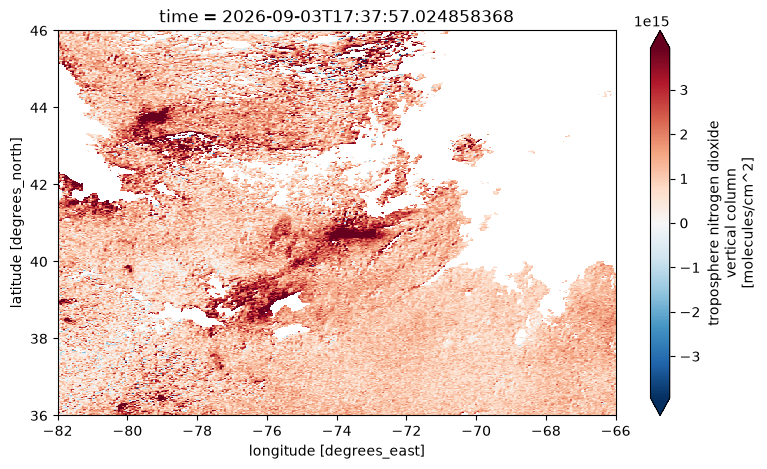

In [5]:
northeast = scan.sel(latitude=slice(36, 46), longitude=slice(-82, -66))
good = northeast.vertical_column_troposphere.where(
    (northeast.main_data_quality_flag == 0) & 
    (northeast.eff_cloud_fraction < 0.5) &
    (northeast.solar_zenith_angle < 80)
)
good.plot(robust=True, figsize=(9, 5));

## Plot a timeseries

A week at the point. Each scan is its own chunk, so a week (about a hundred
scans) is about a hundred chunk reads for each variable touched.

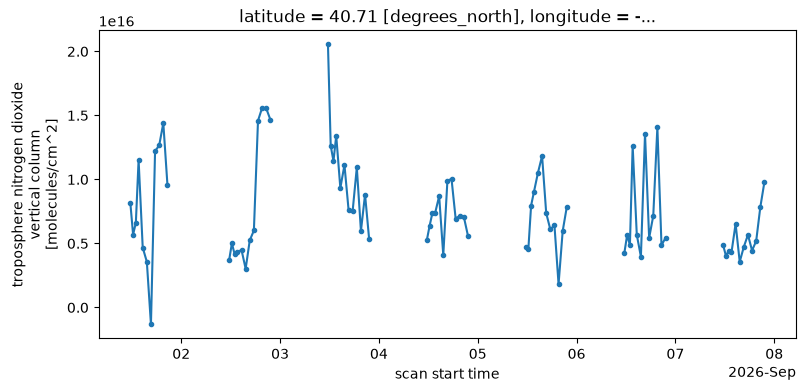

In [6]:
week = ds.sel(time=slice("2026-09-01", "2026-09-07")).sel(**nyc)
good = week.vertical_column_troposphere.where(week.main_data_quality_flag == 0)
good.plot(marker=".", figsize=(9, 4));